## BBC Articles Category Classificatin

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from wordcloud import WordCloud
import string


### Loading Data

Data contains BBC news articles + category

In [2]:
df = pd.read_csv("../Data/bbc-text.csv")
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


### Exploratory Data Analysis (EDA)

In [3]:
number_of_articles_in_each_category = df["category"].value_counts()

number_of_articles_in_each_category


category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

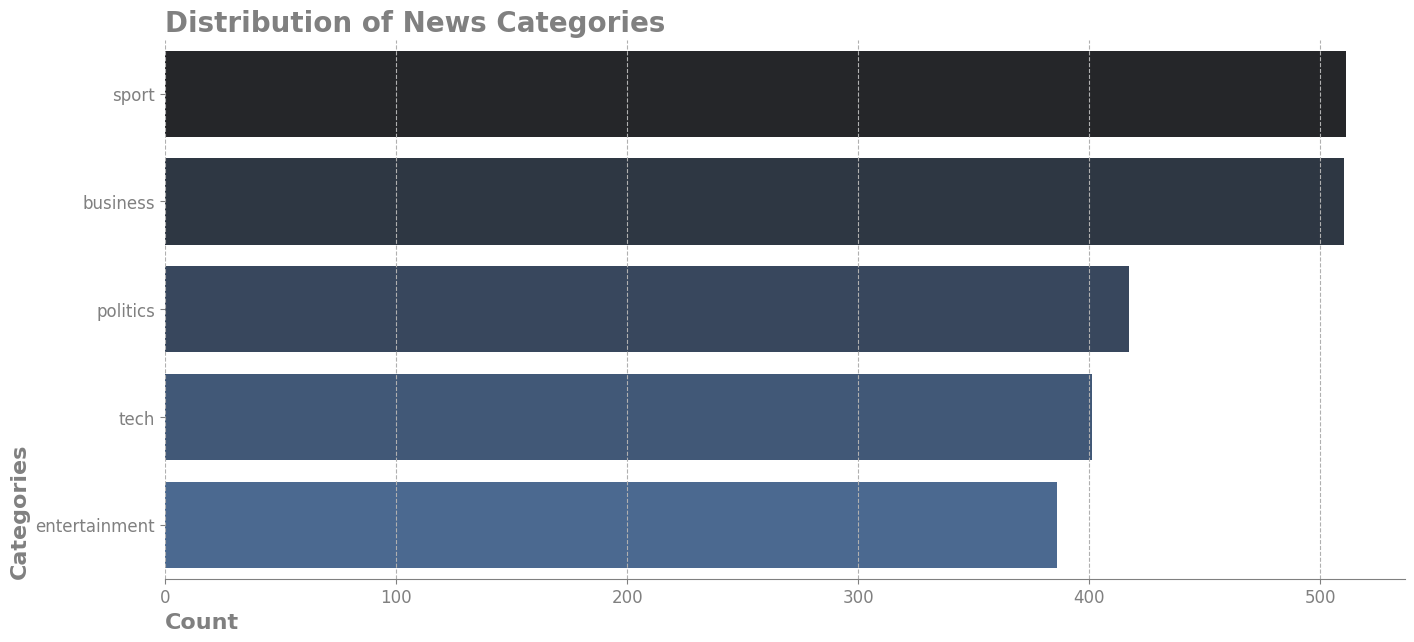

In [4]:
fig ,ax = plt.subplots(figsize = (16,7))
sns.barplot(x = number_of_articles_in_each_category.values,
            y = number_of_articles_in_each_category.index,
            hue = number_of_articles_in_each_category.index,
            palette="dark:#3F679C",
            ax = ax)
ax.spines[["right","left","top"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")
ax.tick_params(axis="x",
               colors= "gray",
               labelsize= "large")
ax.tick_params(axis="y",
               colors= "gray",
               labelsize= "large")

ax.set_title("Distribution of News Categories",
             loc="left",
             weight = "bold",
             color="gray",
             fontsize=20)

ax.set_xlabel("Count",
              loc="left",
              weight="bold",
              fontsize = 16,
              color="gray"
              )
ax.set_ylabel("Categories",
              weight="bold",
              loc="bottom",
              fontsize = 16,
              color="gray")
ax.grid(axis="x", linestyle = "dashed")


### Preprocessing

In [5]:
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(pos_tag):
    if pos_tag.startswith("J"):
        return wordnet.ADJ
    elif pos_tag.startswith("N"):
        return wordnet.NOUN
    elif pos_tag.startswith("V"):
        return wordnet.VERB
    elif pos_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def preprocess_text(text):
    text = text.lower()

    text = text.translate(str.maketrans("","",string.punctuation))

    tokens = word_tokenize(text)

    cleaned_tokens = [token for token in tokens if token not in stop_words]
    
    pos_tags = nltk.pos_tag(cleaned_tokens)
    lemmatized_tokens = [lemmatizer.lemmatize(token,get_wordnet_pos(pos)) for token ,pos in pos_tags]
    processed_articles = " ".join(lemmatized_tokens)


    return processed_articles

df["preprocessed_text"] = df["text"].apply(preprocess_text)


In [6]:
df.head()

,category,text,preprocessed_text
0,tech,tv future in the hands of viewers with home th...,tv future hand viewer home theatre system plas...
1,business,worldcom boss left books alone former worldc...,worldcom bos leave book alone former worldcom ...
2,sport,tigers wary of farrell gamble leicester say ...,tiger wary farrell gamble leicester say rush m...
3,sport,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...
4,entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelve raid box office ocean twelve crim...


### Wordcloud for each Category

In [8]:
tech = df[df["category"] == "tech"] 
tech

,category,text,preprocessed_text
0,tech,tv future in the hands of viewers with home th...,tv future hand viewer home theatre system plas...
19,tech,games maker fights for survival one of britain...,game maker fight survival one britain large in...
20,tech,security warning over fbi virus the us feder...,security warn fbi virus u federal bureau inves...
21,tech,halo 2 heralds traffic explosion the growing p...,halo 2 herald traffic explosion grow popularit...
24,tech,mobile audio enters new dimension as mobile ph...,mobile audio enters new dimension mobile phone...
...,...,...,...
2204,tech,argonaut founder rebuilds empire jez san the ...,argonaut founder rebuilds empire jez san man b...
2207,tech,california sets fines for spyware the makers o...,california set fine spyware maker computer pro...
2213,tech,progress on new internet domains by early 2005...,progress new internet domain early 2005 net co...
2215,tech,junk e-mails on relentless rise spam traffic i...,junk email relentless rise spam traffic 40 put...


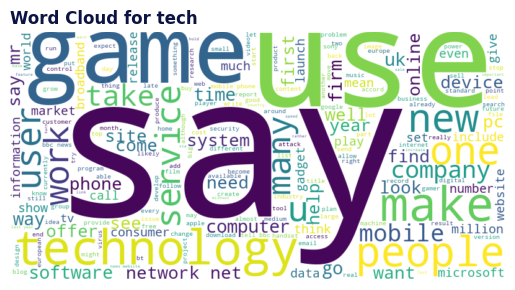

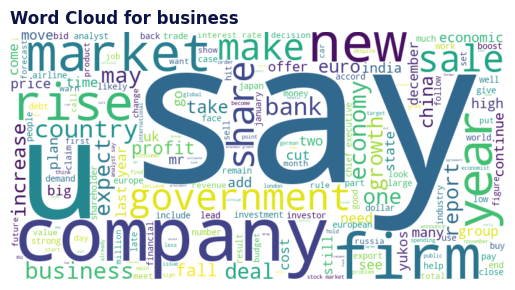

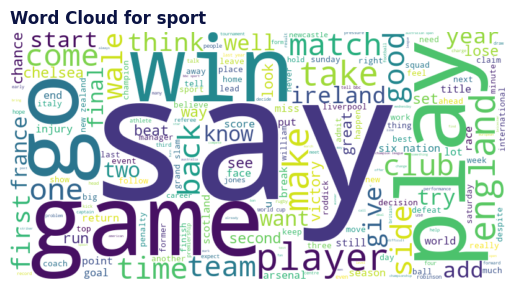

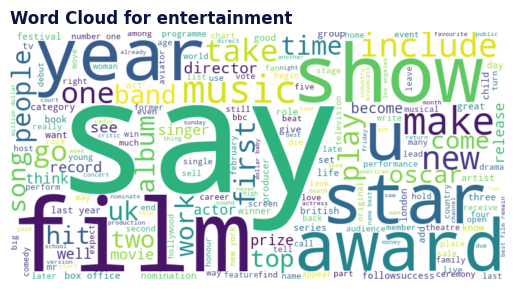

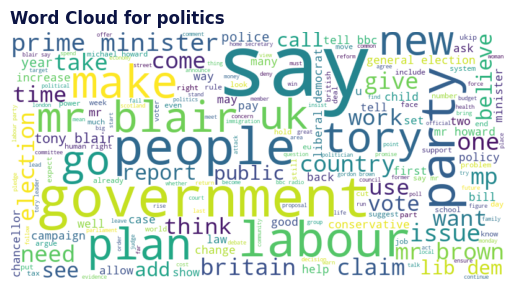

In [18]:
for category in df["category"].unique():
    text =" ".join(df[df["category"] == category]["preprocessed_text"] )
    wordcloud = WordCloud(width=800, height=400,background_color="white").generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    
    plt.title(f"Word Cloud for {category}",
              loc="left",
              color = "#0B1343",
              weight = "bold")
    plt.axis('off')
    plt.show()
